In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\Booksage\Data\books.csv")
df_raw = pd.read_csv("Data/books.csv")
print("Shape:", df_raw.shape)
df_raw.info()


Shape: (6810, 12)
<class 'pandas.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6810 non-null   int64  
 1   isbn10          6810 non-null   str    
 2   title           6810 non-null   str    
 3   subtitle        2381 non-null   str    
 4   authors         6738 non-null   str    
 5   categories      6711 non-null   str    
 6   thumbnail       6481 non-null   str    
 7   description     6548 non-null   str    
 8   published_year  6804 non-null   float64
 9   average_rating  6767 non-null   float64
 10  num_pages       6767 non-null   float64
 11  ratings_count   6767 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 4.3 MB


GENRE DISTRIBTUION

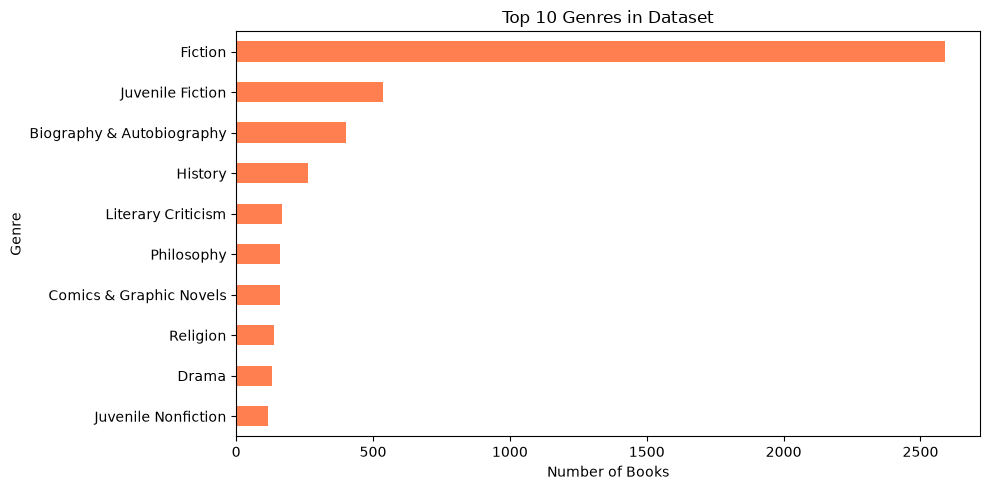

categories
Fiction                      2588
Juvenile Fiction              538
Biography & Autobiography     401
History                       264
Literary Criticism            166
Philosophy                    160
Comics & Graphic Novels       159
Religion                      137
Drama                         132
Juvenile Nonfiction           116
Name: count, dtype: int64


In [5]:
top_genres = df_raw['categories'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_genres.plot(kind='barh', color='coral')
plt.title("Top 10 Genres in Dataset")
plt.xlabel("Number of Books")
plt.ylabel("Genre")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_genres)

Ratings distribution 

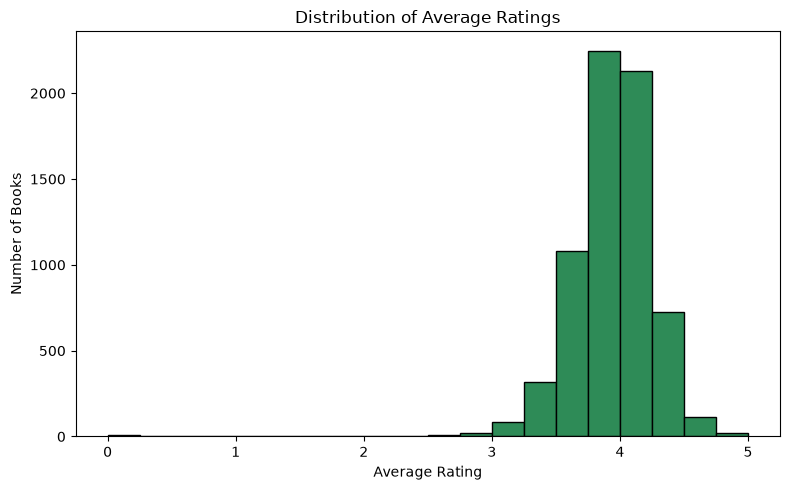

count    6767.000000
mean        3.933284
std         0.331352
min         0.000000
25%         3.770000
50%         3.960000
75%         4.130000
max         5.000000
Name: average_rating, dtype: float64


In [6]:
plt.figure(figsize=(8, 5))
df_raw['average_rating'].dropna().plot(kind='hist', bins=20, color='seagreen', edgecolor='black')
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

print(df_raw['average_rating'].describe())


- The dataset has minimal missing data outside of `subtitle` (65% missing), 
  justifying its removal during cleaning.
- Fiction and Juvenile Fiction dominate the genre distribution.
- Most books cluster around a 3.5-4.5 average rating, suggesting the 
  dataset skews toward generally well-received titles.

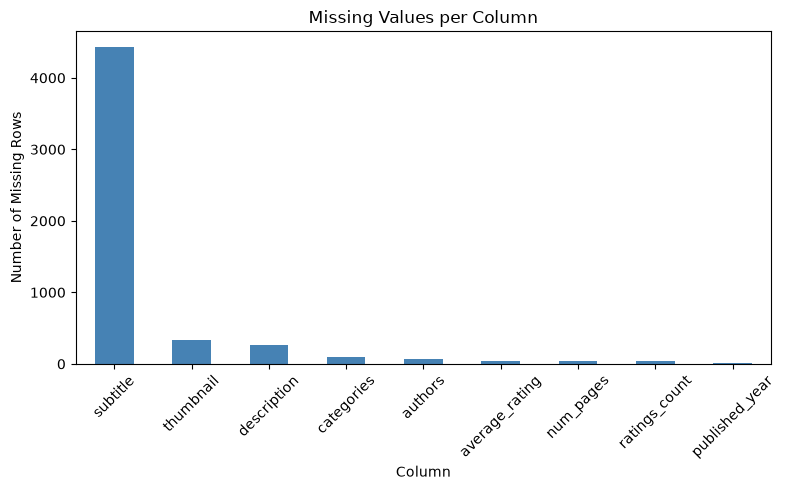

subtitle          4429
thumbnail          329
description        262
categories          99
authors             72
average_rating      43
num_pages           43
ratings_count       43
published_year       6
dtype: int64


In [7]:
missing_counts = df_raw.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
missing_counts.plot(kind='bar', color='steelblue')
plt.title("Missing Values per Column")
plt.ylabel("Number of Missing Rows")
plt.xlabel("Column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(missing_counts)

Keeping the columns we need and renaming columns we need

In [8]:
df = df[['isbn13', 'title', 'authors', 'categories', 'description', 
          'thumbnail', 'average_rating', 'ratings_count']]

df = df.rename(columns={
    'isbn13': 'isbn',
    'categories': 'genre',
    'thumbnail': 'cover_url'
})

How many rows with missing titles will be checked below

In [9]:
print("Missing titles : ",df['title'].isnull().sum())

Missing titles :  0


Fill missing authors and genre with a placeholder instead of dropping the whole row


In [10]:
df['authors'] = df['authors'].fillna('Unknown Author')
df['genre'] = df['genre'].fillna('Unknown')


 Fill missing ratings with 0 = no ratings


In [11]:
df['average_rating'] = df['average_rating'].fillna(0)
df['ratings_count'] = df['ratings_count'].fillna(0)

Track which rows are MISSING a description (to fill via API later)
Temporarily filling missing descriptions with empty string


In [12]:
df['description_missing'] = df['description'].isna()

df['description'] = df['description'].fillna('')


Saving the cleaned version


In [13]:
df.to_csv("Data/books_cleaned.csv", index=False)

print("Cleaning done.")
print("Total rows after cleaning:", len(df))
print("Rows missing description (to fill via API):", df['description_missing'].sum())
print(df.head(3))

Cleaning done.
Total rows after cleaning: 6810
Rows missing description (to fill via API): 262
            isbn         title                          authors  \
0  9780002005883        Gilead               Marilynne Robinson   
1  9780002261982  Spider's Web  Charles Osborne;Agatha Christie   
2  9780006163831  The One Tree             Stephen R. Donaldson   

                           genre  \
0                        Fiction   
1  Detective and mystery stories   
2               American fiction   

                                         description  \
0  A NOVEL THAT READERS and critics have been eag...   
1  A new 'Christie for Christmas' -- a full-lengt...   
2  Volume Two of Stephen Donaldson's acclaimed se...   

                                           cover_url  average_rating  \
0  http://books.google.com/books/content?id=KQZCP...            3.85   
1  http://books.google.com/books/content?id=gA5GP...            3.83   
2  http://books.google.com/books/content?id=OmQaw.

# Step 2: filling missing descriptions using Google Books API

Some books in our cleaned dataset are missing a description.
Here, we use the Google Books API to search for each missing 
book by title and author, and fetch its description if available.
This ensures every book has usable text for our recommendation 
engine later.

In [14]:
import pandas as pd

df = pd.read_csv(r"C:\Users\DELL\Downloads\Booksage\Data\books_cleaned.csv")
print("Total books:", len(df))
print("Missing descriptions:", df['description_missing'].sum())

Total books: 6810
Missing descriptions: 262


Loading the API key

In [15]:
import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("GOOGLE_BOOKS_API_KEY")
print("API key loaded : ",api_key is not None)


API key loaded :  True


In [16]:
import requests
import time

def fetch_description(title, author):
    """
    Given a book title and author, search the Google Books API
    and return the first available description found.
    Returns None if nothing is found or an error occurs.
    """
    query = f"{title} {author}"
    url = f"https://www.googleapis.com/books/v1/volumes?q={query}&key={api_key}"
    
    try:
        response = requests.get(url)
        data = response.json()
        
        if 'items' in data:
            for item in data['items']:
                volume_info = item.get('volumeInfo', {})
                description = volume_info.get('description')
                if description:
                    return description
        return None
    
    except Exception as e:
        print(f"Error fetching '{title}':", e)
        return None

In [17]:
test_row = df[df['description_missing'] == True].iloc[0]
print("Testing on:", test_row['title'], "by", test_row['authors'])

result = fetch_description(test_row['title'], test_row['authors'])
print("Fetched description:", result)

Testing on: The Princess of the Chalet School by Elinor Mary Brent-Dyer
Fetched description: Grizel reluctantly becomes head girl and proves to be worthy of the choice. Soon adventures and mishaps threaten to make her last term an unhappy one, as a hot-headed prefect sets out to disgrace her. Will she rise above it all?


In [18]:
# Get the indices of all rows missing a description
missing_indices = df[df['description_missing'] == True].index

print(f"Fetching descriptions for {len(missing_indices)} books...")

for count, idx in enumerate(missing_indices):
    title = df.loc[idx, 'title']
    author = df.loc[idx, 'authors']
    
    fetched = fetch_description(title, author)
    
    if fetched:
        df.loc[idx, 'description'] = fetched
    
    # Print progress every 20 books
    if (count + 1) % 20 == 0:
        print(f"Processed {count + 1}/{len(missing_indices)} books...")
    
    # Small delay to avoid hitting API rate limits
    time.sleep(0.5)

print("Done fetching all missing descriptions.")

Fetching descriptions for 262 books...
Processed 20/262 books...
Processed 40/262 books...
Processed 60/262 books...
Processed 80/262 books...
Processed 100/262 books...
Processed 120/262 books...
Processed 140/262 books...
Processed 160/262 books...
Processed 180/262 books...
Processed 200/262 books...
Processed 220/262 books...
Processed 240/262 books...
Processed 260/262 books...
Done fetching all missing descriptions.


Recheck how many descriptions are still empty after enrichment

In [19]:
still_missing = (df['description'] == '').sum()
print("Still missing after API enrichment:", still_missing)
print("Successfully filled:", 262 - still_missing)

Still missing after API enrichment: 0
Successfully filled: 262


# Save the fully enriched dataset

In [20]:

df.to_csv("Data/books_final.csv", index=False)

print("Saved final enriched dataset.")
print("Total books:", len(df))
print("Missing descriptions:", (df['description'] == '').sum())

Saved final enriched dataset.
Total books: 6810
Missing descriptions: 0


Text Preprocessing with NLTK

Before building recommendation model, we clean the book descriptions:
Convert text to lowercase
Remove punctuation and numbers
Remove common "stopwords" (the, is, and, etc.) that carry no meaning
Lemmatize words (reduce words to their base form)

This produces cleaner text for  TF-IDF model to work with.

In [21]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer  #imports the tool that reduces words to their base form (e.g., "running" → "run", "better" → "good")
import re #Python's built-in tool for pattern matching in text, using it to strip out punctuation and numbers

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer() 

'''
This creates an instance of NLTK's lemmatizer tool, basically "switching it on" and storing it in a variable called lemmatizer 
Imagine two book descriptions:

Book A: "A detective investigates a murder."
Book B: "A detective investigated several murders."

Without lemmatization, TF-IDF would treat "investigates" and "investigated" as two completely different, unrelated words, even though they mean the exact same thing. This would make your model think these two books are less similar than they actually are, purely because of grammar/tense differences, not actual content differences.
With lemmatization, both become "investigate", so the model correctly recognizes they share the same core concept.
'''

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


'\nThis creates an instance of NLTK\'s lemmatizer tool, basically "switching it on" and storing it in a variable called lemmatizer \nImagine two book descriptions:\n\nBook A: "A detective investigates a murder."\nBook B: "A detective investigated several murders."\n\nWithout lemmatization, TF-IDF would treat "investigates" and "investigated" as two completely different, unrelated words, even though they mean the exact same thing. This would make your model think these two books are less similar than they actually are, purely because of grammar/tense differences, not actual content differences.\nWith lemmatization, both become "investigate", so the model correctly recognizes they share the same core concept.\n'

In [22]:
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk import pos_tag
from nltk.corpus import wordnet

def get_wordnet_pos(tag):
    """
    Converts NLTK's POS tag format into the format WordNetLemmatizer expects.
    """
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Building Text preprocessing Function

In [23]:
def preprocess_text(text):
    """
    Cleans and preprocesses a book description:
    - Lowercase
    - Remove punctuation/numbers
    - Remove stopwords
    - Lemmatize each word using its correct part of speech
    """
    # Safety check: if it's not a string (e.g. NaN/float), return empty string
    if not isinstance(text, str):
        return ''
    
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    tagged_words = pos_tag(words)
    
    cleaned_words = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag)) 
        for word, tag in tagged_words
    ]
    
    return ' '.join(cleaned_words)

In [24]:
sample_text = "The detectives were investigating multiple murders across the city."
print("Original:", sample_text)
print("Cleaned:", preprocess_text(sample_text))

Original: The detectives were investigating multiple murders across the city.
Cleaned: detective investigate multiple murder across city


Applying preprocessing to whole dataset

In [25]:
print("Preprocessing all descriptions... this may take a minute.")

df['cleaned_description'] = df['description'].apply(preprocess_text)

print("Done. Sample comparison:")
print(df[['description', 'cleaned_description']].head(3))

Preprocessing all descriptions... this may take a minute.
Done. Sample comparison:
                                         description  \
0  A NOVEL THAT READERS and critics have been eag...   
1  A new 'Christie for Christmas' -- a full-lengt...   
2  Volume Two of Stephen Donaldson's acclaimed se...   

                                 cleaned_description  
0  novel reader critic eagerly anticipate decade ...  
1  new christie christmas fulllength novel adapt ...  
2  volume two stephen donaldsons acclaim second t...  


In [26]:
df.to_csv("Data/books_preprocessed.csv", index=False)

print("Saved preprocessed dataset.")
print("Total books:", len(df))
print("Columns:", df.columns.tolist())

Saved preprocessed dataset.
Total books: 6810
Columns: ['isbn', 'title', 'authors', 'genre', 'description', 'cover_url', 'average_rating', 'ratings_count', 'description_missing', 'cleaned_description']


Recommendation Engine (TF-IDF + Cosine Similarity)

We convert each book's cleaned description into a TF-IDF vector capturing 
which words are distinctive for that book. Then we use cosine similarity 
to measure how alike two books are, allowing us to recommend similar books.

In [27]:
import pandas as pd
#Loading fully preprocessed dataset
df = pd.read_csv("Data/books_preprocessed.csv")
print("Total books:", len(df))
print(df[['title', 'cleaned_description']].head(3))

Total books: 6810
          title                                cleaned_description
0        Gilead  novel reader critic eagerly anticipate decade ...
1  Spider's Web  new christie christmas fulllength novel adapt ...
2  The One Tree  volume two stephen donaldsons acclaim second t...


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df['cleaned_description'] = df['cleaned_description'].fillna('')

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['cleaned_description'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("TF-IDF shape:", tfidf_matrix.shape)
print("Cosine similarity shape:", cosine_sim.shape)

TF-IDF shape: (6810, 30771)
Cosine similarity shape: (6810, 6810)


Multi-Book Recommendations with Genre-Based Explanation

Users can input up to 5 books they've liked. We combine their TF-IDF 
vectors, find the most similar books overall, and explain each 
recommendation with a simple genre-based reason.

In [29]:
import numpy as np

def get_recommendations_multi(liked_titles, num_recommendations=5):
    """
    Given a list of up to 5 book titles the user liked, returns the 
    top N most similar books overall, with a simple genre-based explanation.
    """
    liked_indices = []
    liked_genres = set()
    
    # Step 1: Find each liked book in the dataset
    for title in liked_titles:
        matches = df[df['title'].str.lower() == title.lower()]
        if matches.empty:
            print(f"'{title}' not found in dataset, skipping.")
            continue
        idx = matches.index[0]
        liked_indices.append(idx)
        liked_genres.add(df.loc[idx, 'genre'])
    
    if not liked_indices:
        print("None of the entered books were found.")
        return None
    
    # Step 2: Average the TF-IDF vectors of all liked books
    liked_vectors = tfidf_matrix[liked_indices]
    avg_vector = np.asarray(liked_vectors.mean(axis=0))
    
    # Step 3: Compute similarity between this averaged "profile" and every book
    sim_scores = cosine_similarity(avg_vector, tfidf_matrix)[0]
    
    # Step 4: Sort by similarity, excluding books the user already liked
    sim_scores = list(enumerate(sim_scores))
    sim_scores = [s for s in sim_scores if s[0] not in liked_indices]
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[:num_recommendations]
    
    # Step 5: Build results with simple genre-based explanation
    book_indices = [i[0] for i in sim_scores]
    recommendations = df.iloc[book_indices][['title', 'authors', 'genre']].copy()
    recommendations['similarity_score'] = [score for _, score in sim_scores]
    recommendations['explanation'] = recommendations['genre'].apply(
        lambda g: f"Recommended because it shares the {g} genre with books you entered."
    )
    
    return recommendations

In [30]:
from sklearn.metrics.pairwise import cosine_similarity as cosine_sim_func

def get_recommendations_with_fallback(title, author="", num_recommendations=5):
    """
    Recommends books similar to the given title.
    If the book isn't in the dataset, fetches its description
    from the Google Books API and computes similarity on the fly.
    """
    matches = df[df['title'].str.lower() == title.lower()]
    
    if not matches.empty:
        return get_recommendations_multi([title], num_recommendations)
    
    print(f"'{title}' not found in dataset. Fetching from Google Books API...")
    description = fetch_description(title, author)
    
    if not description:
        print(f"Could not find any description for '{title}'. Try a different title.")
        return None
    
    cleaned = preprocess_text(description)
    new_vector = tfidf.transform([cleaned])
    
    sim_scores = cosine_sim_func(new_vector, tfidf_matrix)[0]
    sim_scores = list(enumerate(sim_scores))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[:num_recommendations]
    
    book_indices = [i[0] for i in sim_scores]
    recommendations = df.iloc[book_indices][['title', 'authors', 'genre']].copy()
    recommendations['similarity_score'] = [score for _, score in sim_scores]
    
    recommendations['explanation'] = recommendations['genre'].apply(
        lambda g: f"Recommended because it shares the {g} genre with '{title}'."
    )
    
    return recommendations

In [31]:
liked_books = ["The One Tree", "Gilead", "Spider's Web"]
recommendations = get_recommendations_multi(liked_books)

for i, row in recommendations.iterrows():
    print(f"\n📖 {row['title']} by {row['authors']}")
    print(f"Similarity: {row['similarity_score']:.3f}")
    print(row['explanation'])


📖 Witness for the Prosecution & Selected Plays by Agatha Christie
Similarity: 0.138
Recommended because it shares the English drama genre with books you entered.

📖 Legends by George R. R. Martin;Anne McCaffrey
Similarity: 0.120
Recommended because it shares the Fiction genre with books you entered.

📖 The Brothers Karamazov by Fyodor Dostoevsky
Similarity: 0.113
Recommended because it shares the Fiction genre with books you entered.

📖 The Brothers Karamazov by Fyodor Dostoyevsky
Similarity: 0.113
Recommended because it shares the Fiction genre with books you entered.

📖 A Dark and Hungry God Arises by Stephen R. Donaldson
Similarity: 0.111
Recommended because it shares the Fiction genre with books you entered.


Genre based Recommendation

In [32]:
def get_recommendations_by_genre(genre, num_recommendations=5):
    """
    Given a genre, returns the top N highest-rated books in that genre.
    """
    genre_books = df[df['genre'].str.lower() == genre.lower()]
    
    if genre_books.empty:
        print(f"No books found for genre '{genre}'.")
        return None
    
    # Sort by rating and number of ratings (popularity + quality)
    top_books = genre_books.sort_values(
        by=['average_rating', 'ratings_count'], ascending=False
    ).head(num_recommendations)
    
    recommendations = top_books[['title', 'authors', 'genre', 'average_rating']].copy()
    recommendations['explanation'] = recommendations['genre'].apply(
        lambda g: f"Recommended because it is a top-rated {g} book."
    )
    
    return recommendations

In [33]:
recommendations = get_recommendations_by_genre("Fiction")
for i, row in recommendations.iterrows():
    print(f"\n📖 {row['title']} by {row['authors']} (Rating: {row['average_rating']})")
    print(row['explanation'])


📖 Novels, 1901-1902 by Henry James;Leo Bersani (Rating: 4.68)
Recommended because it is a top-rated Fiction book.

📖 The Shining by Stephen King (Rating: 4.67)
Recommended because it is a top-rated Fiction book.

📖 The Hobbit / The Lord of the Rings by John Ronald Reuel Tolkien (Rating: 4.59)
Recommended because it is a top-rated Fiction book.

📖 Collected Fictions by Jorge Luis Borges;Andrew Hurley (Rating: 4.58)
Recommended because it is a top-rated Fiction book.

📖 The More Than Complete Hitchhiker's Guide by Douglas Adams (Rating: 4.58)
Recommended because it is a top-rated Fiction book.


Mood-Based Recommendations

Users can select a mood (e.g., "Thrilling", "Relaxing", "Emotional"), 
which maps to relevant genres and keywords in our dataset, to surface 
matching books.

In [34]:
import re

# Mapping moods to relevant genres and keywords found in the dataset
mood_map = {
    "Thrilling": {
        "genres": ["Detective and mystery stories", "Thrillers (Fiction)", "Suspense"],
        "keywords": ["murder", "kill", "danger", "chase", "escape"]
    },
    "Relaxing": {
        "genres": ["Cooking", "Nature", "Travel"],
        "keywords": ["peaceful", "calm", "journey", "garden", "home"]
    },
    "Emotional": {
        "genres": ["Fiction", "Biography & Autobiography"],
        "keywords": ["love", "loss", "family", "heart", "life"]
    },
    "Adventurous": {
        "genres": ["Adventure stories", "Fantasy fiction", "Science fiction"],
        "keywords": ["quest", "journey", "battle", "magic", "world"]
    },
    "Funny": {
        "genres": ["Humor", "Comedy"],
        "keywords": ["funny", "comedy", "laugh", "hilarious", "joke"]
    }
}

def get_recommendations_by_mood(mood, num_recommendations=5):
    """
    Given a mood, returns top books matching relevant genres,
    ranked by rating.
    """
    if mood not in mood_map:
        print(f"Mood '{mood}' not recognized. Choose from: {list(mood_map.keys())}")
        return None
    
    genres = mood_map[mood]["genres"]
    
    # Escape special regex characters so parentheses etc. are treated as plain text
    pattern = '|'.join(re.escape(g) for g in genres)
    mood_books = df[df['genre'].str.contains(pattern, case=False, na=False)]
    
    if mood_books.empty:
        print(f"No books found matching mood '{mood}'.")
        return None
    
    top_books = mood_books.sort_values(
        by=['average_rating', 'ratings_count'], ascending=False
    ).head(num_recommendations)
    
    recommendations = top_books[['title', 'authors', 'genre', 'average_rating']].copy()
    recommendations['explanation'] = recommendations['genre'].apply(
        lambda g: f"Recommended for your '{mood}' mood, matching genre: {g}."
    )
    
    return recommendations

In [35]:
recommendations = get_recommendations_by_mood("Thrilling")
for i, row in recommendations.iterrows():
    print(f"\n📖 {row['title']} by {row['authors']} (Rating: {row['average_rating']})")
    print(row['explanation'])


📖 The New Annotated Sherlock Holmes by Arthur Conan Doyle (Rating: 4.63)
Recommended for your 'Thrilling' mood, matching genre: Detective and mystery stories, English.

📖 The Novels by Arthur Conan Doyle (Schriftsteller, Grossbritannien) (Rating: 4.54)
Recommended for your 'Thrilling' mood, matching genre: Detective and mystery stories, English.

📖 Raymond Chandler: Stories & Early Novels (LOA #79) by Raymond Chandler (Rating: 4.49)
Recommended for your 'Thrilling' mood, matching genre: Detective and mystery stories, American.

📖 The Complete Sherlock Holmes: Some personalia about Mr. Sherlock Holmes by Sir Arthur Conan Doyle (Rating: 4.49)
Recommended for your 'Thrilling' mood, matching genre: Detective and mystery stories, English.

📖 Sherlock Holmes the Complete Novels and Stories Book Discussion Kit by Unknown Author (Rating: 4.47)
Recommended for your 'Thrilling' mood, matching genre: Detective and mystery stories.


In [36]:
recommendations = get_recommendations_with_fallback("The Housemaid", "Freida McFadden")
print(recommendations)


'The Housemaid' not found in dataset. Fetching from Google Books API...
                             title           authors      genre  \
6073                       Letters        John Barth    Fiction   
876                Jamie's Kitchen      Jamie Oliver    Cookery   
3376                     Hogfather   Terry Pratchett  Christmas   
252              The Reading Group   Elizabeth Noble    Fiction   
554   The First Forty-nine Stories  Ernest Hemingway    Fiction   

      similarity_score                                        explanation  
6073          0.128669  Recommended because it shares the Fiction genr...  
876           0.117388  Recommended because it shares the Cookery genr...  
3376          0.116720  Recommended because it shares the Christmas ge...  
252           0.113193  Recommended because it shares the Fiction genr...  
554           0.106770  Recommended because it shares the Fiction genr...  
